# 第 12 章 · FrozenLake MCTS / UCT 代码实验

[章节网页](../ch12.html)

## 运行内容

- 加载 FrozenLake-v1
- 运行 UCT 模拟
- 绘制访问价值

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 第 11 章使用 Gymnasium 经典环境，保持和官方教程一致的环境接口。
if importlib.util.find_spec("gymnasium") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium>=0.29"])

import gymnasium as gym

In [3]:
# FrozenLake-v1：用 UCT 从起点做 Monte Carlo Tree Search。
mcts_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
mcts_P = mcts_env.unwrapped.P
mcts_map = np.array([
    [cell.decode("utf-8") if isinstance(cell, bytes) else str(cell) for cell in row]
    for row in mcts_env.unwrapped.desc
])
mcts_actions = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}
mcts_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
root_state = 0
rng = np.random.default_rng(12)
N_state = defaultdict(int)
N_action = defaultdict(int)
W_action = defaultdict(float)

def sample_model_step(state, action):
    outcomes = mcts_P[state][action]
    probs = np.array([item[0] for item in outcomes], dtype=float)
    probs = probs / probs.sum()
    idx = rng.choice(len(outcomes), p=probs)
    prob, next_state, reward, done = outcomes[idx]
    return next_state, reward, done


def uct_action(state, c=1.4):
    for action in range(mcts_env.action_space.n):
        if N_action[(state, action)] == 0:
            return action
    scores = []
    for action in range(mcts_env.action_space.n):
        mean_value = W_action[(state, action)] / N_action[(state, action)]
        explore = c * np.sqrt(np.log(N_state[state] + 1) / N_action[(state, action)])
        scores.append(mean_value + explore)
    return int(np.argmax(scores))


def rollout(state, depth_limit=18, gamma=0.99):
    total = 0.0
    discount = 1.0
    for _ in range(depth_limit):
        action = rng.integers(mcts_env.action_space.n)
        state, reward, done = sample_model_step(state, int(action))
        total += discount * reward
        discount *= gamma
        if done:
            break
    return total


simulation_rows = []
for simulation in range(1, 1201):
    state = root_state
    path = []
    total_reward = 0.0
    discount = 1.0
    done = False
    for depth in range(18):
        action = uct_action(state)
        path.append((state, action))
        next_state, reward, done = sample_model_step(state, action)
        total_reward += discount * reward
        discount *= 0.99
        state = next_state
        if done:
            break
    if not done:
        total_reward += discount * rollout(state)

    for state, action in path:
        N_state[state] += 1
        N_action[(state, action)] += 1
        W_action[(state, action)] += total_reward
    if simulation % 200 == 0:
        simulation_rows.append({"simulation": simulation, "root_visits": N_state[root_state]})

root_rows = []
for action in range(mcts_env.action_space.n):
    visits = N_action[(root_state, action)]
    mean_value = W_action[(root_state, action)] / visits if visits else 0
    explore = 1.4 * np.sqrt(np.log(N_state[root_state] + 1) / visits) if visits else 0
    root_rows.append({
        "action": mcts_actions[action],
        "visits": visits,
        "mean_value": mean_value,
        "explore": explore,
        "UCT": mean_value + explore,
    })

mcts_root_df = pd.DataFrame(root_rows).sort_values("UCT", ascending=False).reset_index(drop=True)
mcts_sim_df = pd.DataFrame(simulation_rows)
display(pd.DataFrame(mcts_map))
display(mcts_root_df.round(4))
print("root action:", mcts_root_df.loc[0, "action"])

,0,1,2,3
0,S,F,F,F
1,F,H,F,H
2,F,F,F,H
3,H,F,F,G


,action,visits,mean_value,explore,UCT
0,Down,961,0.0139,0.1298,0.1437
1,Up,834,0.0043,0.1393,0.1437
2,Right,848,0.0055,0.1382,0.1437
3,Left,1232,0.0286,0.1147,0.1432


root action: Down


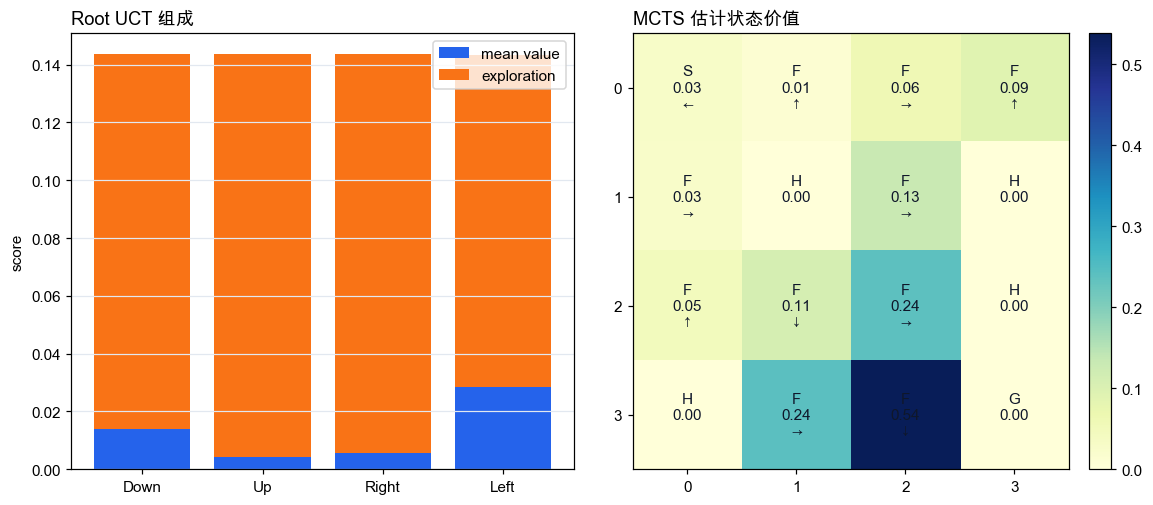

In [4]:
# 绘制根节点动作统计和 MCTS 访问到的状态价值。
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.7))
x = np.arange(len(mcts_root_df))
axes[0].bar(x, mcts_root_df["mean_value"], color="#2563eb", label="mean value")
axes[0].bar(x, mcts_root_df["explore"], bottom=mcts_root_df["mean_value"], color="#f97316", label="exploration")
axes[0].set_xticks(x, mcts_root_df["action"])
axes[0].set_title("Root UCT 组成", loc="left", fontweight="bold")
axes[0].set_ylabel("score")
axes[0].grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
axes[0].legend()

value_grid = np.zeros(16)
policy_grid = np.full(16, -1)
for state in range(16):
    values = []
    for action in range(mcts_env.action_space.n):
        visits = N_action[(state, action)]
        values.append(W_action[(state, action)] / visits if visits else np.nan)
    if not np.all(np.isnan(values)):
        policy_grid[state] = int(np.nanargmax(values))
        value_grid[state] = float(np.nanmax(values))
value_grid = value_grid.reshape(4, 4)
policy_grid = policy_grid.reshape(4, 4)

im = axes[1].imshow(value_grid, cmap="YlGnBu", vmin=0, vmax=max(0.01, value_grid.max()))
for state in range(16):
    r, c = divmod(state, 4)
    tile = mcts_map[r, c]
    arrow = "" if tile in {"H", "G"} or policy_grid[r, c] < 0 else mcts_arrows[int(policy_grid[r, c])]
    axes[1].text(c, r, f"{tile}\n{value_grid[r, c]:.2f}\n{arrow}", ha="center", va="center", color="#0f172a", fontweight="bold")
axes[1].set_title("MCTS 估计状态价值", loc="left", fontweight="bold")
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()